# Kadir Cihan Duran PLSC 508 HW1

In this homework, I used Swiss climate policy network analyzed in

> Minhas, S., Hoff, P. D., & Ward, M. D. (2019). *Inferential Approaches for Network Analysis: AMEN for Latent Factor Models.* **Political Analysis**, 27(2), 208–222. (Replication data: doi:10.7910/DVN/H31DZG)


In [1]:
import numpy as np
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

SEED = 19880106

nodes = pd.read_csv("nodes.csv")
edges = pd.read_csv("edges.csv")

G = nx.DiGraph()
for _, r in nodes.iterrows():
    G.add_node(r["id"], orgtype=r["orgtype"])
G.add_edges_from(zip(edges["from"], edges["to"]))

U = G.to_undirected()

print(f"Nodes: {G.number_of_nodes()} | Directed edges: {G.number_of_edges()} | "
      f"Undirected edges: {U.number_of_edges()}")
print(f"Density (directed): {nx.density(G):.3f} | Isolates: {len(list(nx.isolates(G)))} | "
      f"Weakly connected components: {nx.number_weakly_connected_components(G)}")
print("\nActors by organization type:")
print(nodes["orgtype"].value_counts().to_string())

Nodes: 34 | Directed edges: 207 | Undirected edges: 161
Density (directed): 0.184 | Isolates: 0 | Weakly connected components: 1

Actors by organization type:
orgtype
private    11
ngo         7
science     6
party       5
gov         5


## 1. Visualising network with Fruchterman–Reingold layout

I use Fruchterman–Reingold algorithm for visualization. It is a force-directed layout. It treats the graph as a physical system and iteratively moves vertices until the forces balance. In this algorithm, densely connected groups sit close together and weakly connected actors are pushed to the periphery. Because the starting positions are random, I set the seed, so it makes the visual reproducible and lets me reuse exactly the same coordinates in Sections 2 and 4. In NetworkX, `spring_layout` implements the Fruchterman–Reingold algorithm. I set color of the nodes as organization types of the nodes.

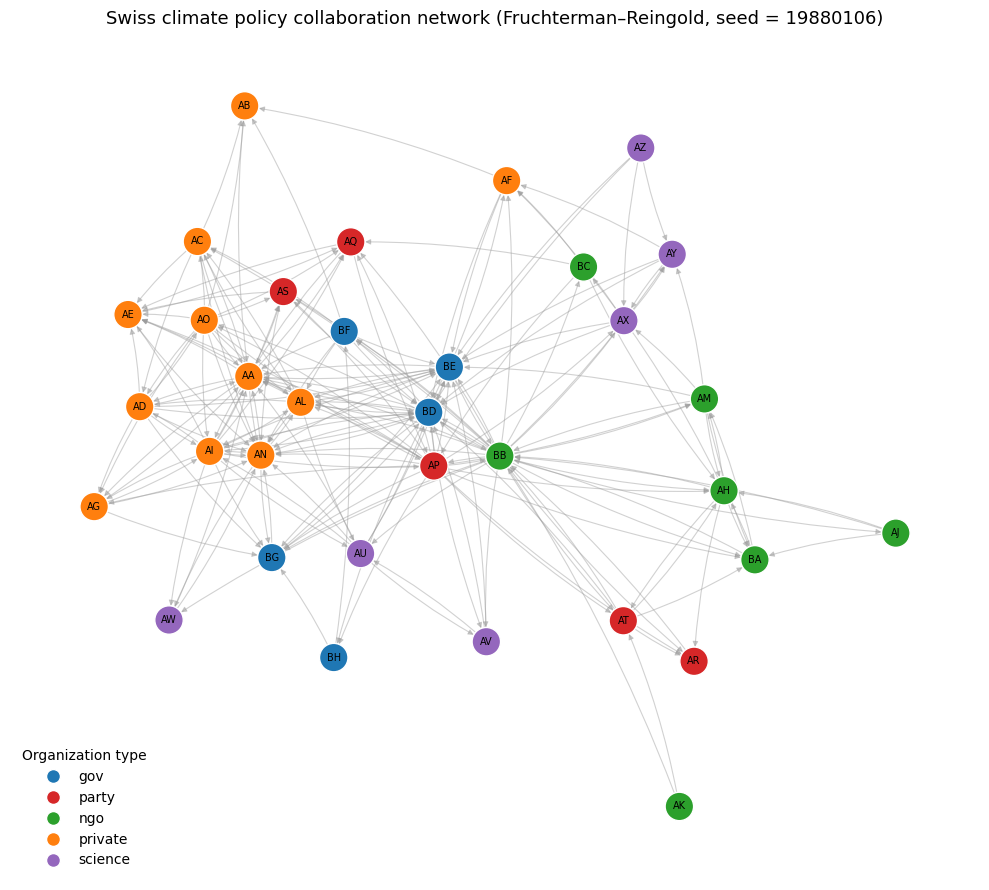

In [2]:
pos = nx.spring_layout(U, seed=SEED, k=0.45, iterations=200)

type_colors = {"gov": "#1f77b4", "party": "#d62728", "ngo": "#2ca02c",
               "private": "#ff7f0e", "science": "#9467bd"}
node_type_col = [type_colors[G.nodes[v]["orgtype"]] for v in G]

def draw_base(ax, node_size=350, node_color="#888888", title=""):
    nx.draw_networkx_edges(G, pos, ax=ax, edge_color="#9a9a9a", alpha=0.45, width=0.8,
                           arrows=True, arrowstyle="-|>", arrowsize=8,
                           node_size=node_size, connectionstyle="arc3,rad=0.06")
    nx.draw_networkx_nodes(G, pos, ax=ax, node_size=node_size, node_color=node_color,
                           edgecolors="white", linewidths=1.0)
    nx.draw_networkx_labels(G, pos, ax=ax, font_size=7, font_color="black")
    ax.set_title(title, fontsize=13); ax.axis("off")

fig, ax = plt.subplots(figsize=(10, 9))
draw_base(ax, node_size=420, node_color=node_type_col,
          title="Swiss climate policy collaboration network (Fruchterman–Reingold, seed = 19880106)")
handles = [Line2D([0], [0], marker="o", color="w", markerfacecolor=c, markersize=10, label=t)
           for t, c in type_colors.items()]
ax.legend(handles=handles, title="Organization type", loc="lower left", frameon=False)
plt.tight_layout(); plt.show()

Network forms a single connected component with no isolates, so every actor reaches every other one through some chain of collaboration. Density is moderate (≈ 0.18): about 18% of all possible directed ties are present. The Fruchterman–Reingold layout already shows structure:

* Government agencies (blue), especially BD and BE, and the large NGO BB sit in the core, where many ties cross.
* Private-sector actors (orange) cluster on one side and NGOs (green) together with parties (red) on another. Collaboration therefore appears to follow organization type.
* Scientific institutions (purple) sit near the government agencies, but several of them, such as AZ, AY, AW, lie at the edge of the layout with few ties.

## 2. Centrality: degree, betweenness and eigenvector

I analyze degree, betweenness, and eigenvector centralities in this section.

In [3]:
deg = nx.degree_centrality(U)
btw = nx.betweenness_centrality(G, normalized=True)
eig = nx.eigenvector_centrality(U, max_iter=1000)

cent = pd.DataFrame({
    "orgtype":     nx.get_node_attributes(G, "orgtype"),
    "in_degree":   dict(G.in_degree()),
    "out_degree":  dict(G.out_degree()),
    "degree":      deg,
    "betweenness": btw,
    "eigenvector": eig,
}).round(3)

print("Top 8 actors by each centrality measure")
top = pd.concat({m: cent.sort_values(m, ascending=False).head(8)[["orgtype", m]].reset_index()
                     .rename(columns={"index": "actor"})
                 for m in ["degree", "betweenness", "eigenvector"]}, axis=1)
display(top)

Top 8 actors by each centrality measure


degree                 betweenness                      eigenvector  \
   actor  orgtype degree       actor  orgtype betweenness       actor   
0     BB      ngo  0.788          BB      ngo       0.340          BB   
1     AP    party  0.636          BD      gov       0.206          AA   
2     BD      gov  0.576          BE      gov       0.122          AP   
3     AA  private  0.545          AA  private       0.117          AN   
4     BE      gov  0.515          AP    party       0.099          BD   
5     AN  private  0.515          AI  private       0.075          BE   
6     AI  private  0.455          AN  private       0.052          AI   
7     AL  private  0.394          AL  private       0.029          AL   

                        
   orgtype eigenvector  
0      ngo       0.310  
1  private       0.289  
2    party       0.289  
3  private       0.286  
4      gov       0.274  
5      gov       0.257  
6  private       0.249  
7  private       0.244

In [4]:
print("Mean centrality by organization type")
display(cent.groupby("orgtype")[["in_degree", "out_degree", "degree", "betweenness", "eigenvector"]]
        .mean().round(3).sort_values("degree", ascending=False))

print("Spearman rank correlation between measures")
display(cent[["degree", "betweenness", "eigenvector", "in_degree", "out_degree"]]
        .corr(method="spearman").round(2))

Mean centrality by organization type


,in_degree,out_degree,degree,betweenness,eigenvector
orgtype,,,,,
gov,9.400,5.800,0.352,0.073,0.186
private,7.818,6.818,0.344,0.030,0.194
party,5.000,6.200,0.285,0.025,0.148
ngo,4.286,7.000,0.247,0.051,0.101
science,3.167,3.833,0.176,0.002,0.102


Spearman rank correlation between measures


,degree,betweenness,eigenvector,in_degree,out_degree
degree,1.00,0.92,0.96,0.78,0.81
betweenness,0.92,1.00,0.87,0.74,0.81
eigenvector,0.96,0.87,1.00,0.75,0.75
in_degree,0.78,0.74,0.75,1.00,0.43
out_degree,0.81,0.81,0.75,0.43,1.00


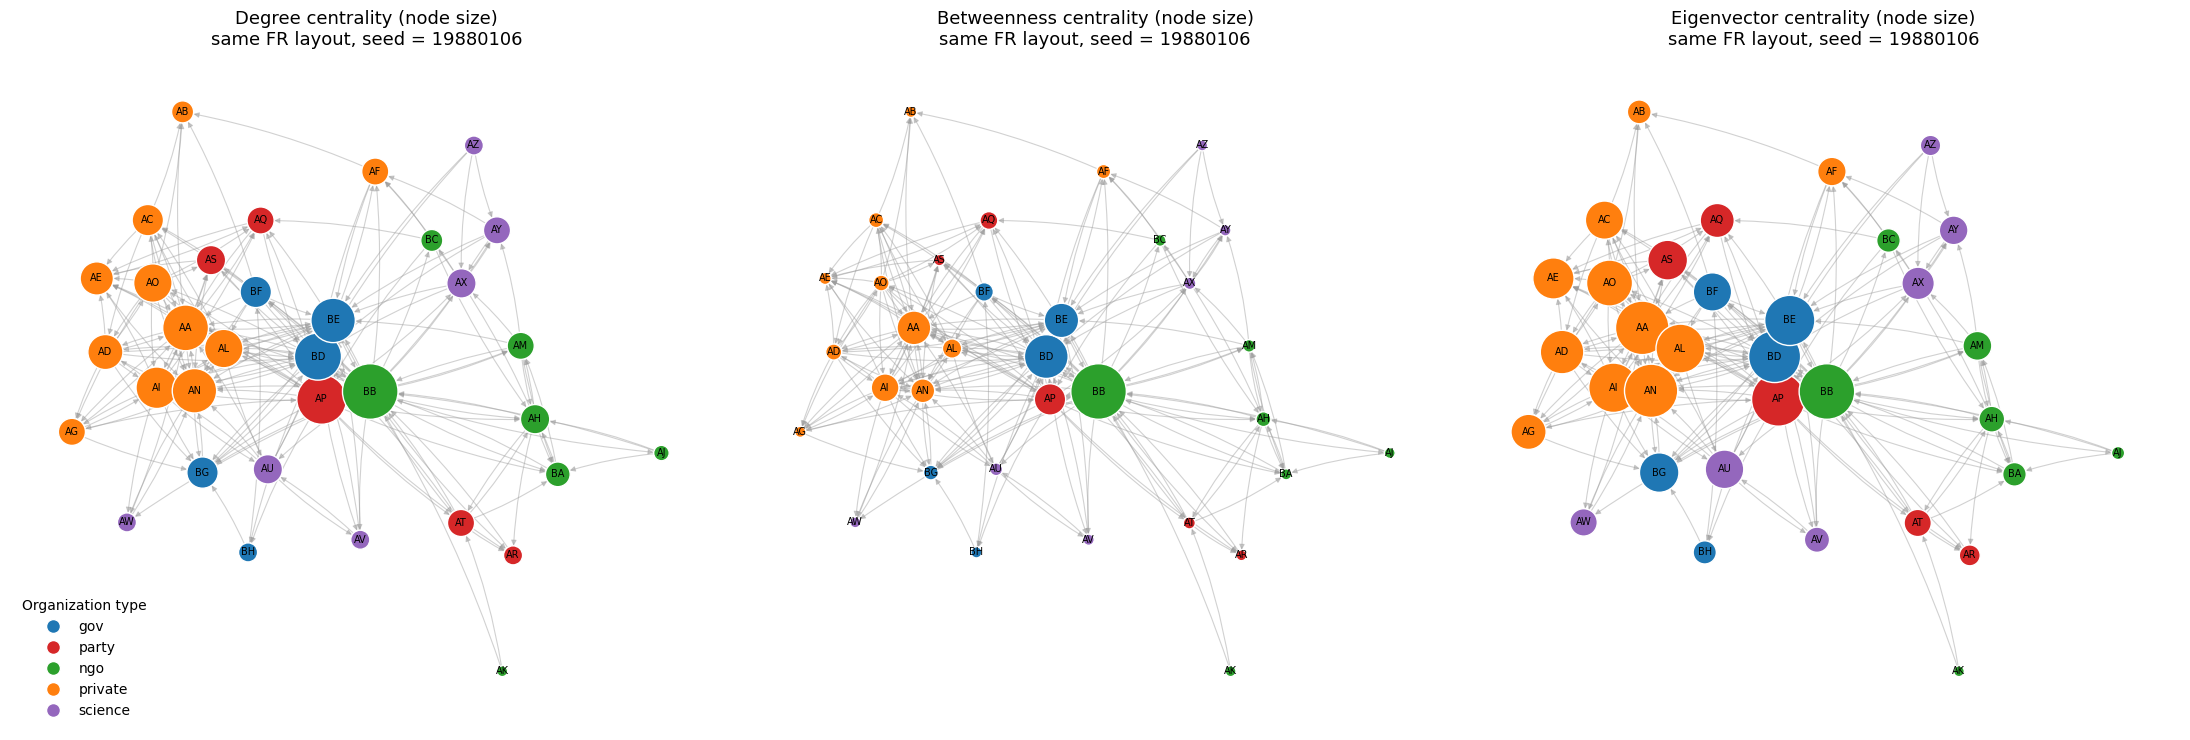

In [5]:
def scale(x, lo=60, hi=1600):
    x = np.asarray(x, dtype=float)
    return lo + (x - x.min()) / (x.max() - x.min()) * (hi - lo)

fig, axes = plt.subplots(1, 3, figsize=(22, 7.5))
for ax, (name, vals) in zip(axes, [("Degree", deg), ("Betweenness", btw), ("Eigenvector", eig)]):
    sizes = scale([vals[v] for v in G])
    draw_base(ax, node_size=sizes, node_color=node_type_col,
              title=f"{name} centrality (node size)\nsame FR layout, seed = 19880106")
axes[0].legend(handles=handles, title="Organization type", loc="lower left", frameon=False)
plt.tight_layout(); plt.show()

* The NGO BB is the most central actor on all three measures. It is tied to ≈ 79% of the other actors (degree 0.79) and has by far the highest betweenness (≈ 0.34). Roughly a third of all shortest paths pass through it, so BB acts as the main broker between the NGO/party side and the rest of the network.
* By organization type, government and private actors have the highest average degree and eigenvector centrality. Scientific institutions are the most peripheral: their mean betweenness (≈ 0.002) is close to zero.
* The measures are strongly correlated (Spearman ρ ≈ 0.87–0.96), so the same core actors dominate on all of them. Betweenness is the most concentrated measure: in the figure, a few brokers (BB, BD, BE, AA) have large nodes while most others shrink to small points. Eigenvector centrality is more evenly spread, because peripheral actors still benefit from being tied to the well-connected core.

## 3. Transitivity and reciprocity

In this section, I analyze transitivity and reciprocity values of the graph. To judge whether these values are high or low, I compare them with 1,000 random directed graphs that have the same number of nodes and edges.

In [6]:
recip = nx.reciprocity(G)
mutual = sum(1 for u, v in G.edges if G.has_edge(v, u)) // 2
asym = G.number_of_edges() - 2 * mutual
n = G.number_of_nodes(); null = n * (n - 1) // 2 - mutual - asym
dyadic_recip = mutual / (mutual + asym)
trans = nx.transitivity(U)
avg_clust = nx.average_clustering(U)

rng_r, rng_t, rng_c = [], [], []
for s in range(1000):
    H = nx.gnm_random_graph(n, G.number_of_edges(), directed=True, seed=s)
    Hu = H.to_undirected()
    rng_r.append(nx.reciprocity(H)); rng_t.append(nx.transitivity(Hu))

def row(name, obs, sims):
    sims = np.array(sims)
    return {"Measure": name, "Observed": round(obs, 3),
            "Random G(n,m): mean": round(sims.mean(), 3), "Random G(n,m): SD": round(sims.std(), 3),
            "z-score": round((obs - sims.mean()) / sims.std(), 1),
            "Ratio obs / random": round(obs / sims.mean(), 2)}

results = pd.DataFrame([
    row("Reciprocity", recip, rng_r),
    row("Transitivity", trans, rng_t),
])
display(results)

dyads = pd.DataFrame({"Dyad type": ["Mutual (i↔j)", "Asymmetric (i→j only)", "Null (no tie)", "Total"],
                      "Count": [mutual, asym, null, mutual + asym + null]})
display(dyads)

,Measure,Observed,"Random G(n,m): mean","Random G(n,m): SD",z-score,Ratio obs / random
0,Reciprocity,0.444,0.183,0.034,7.6,2.43
1,Transitivity,0.510,0.333,0.016,10.9,1.53


,Dyad type,Count
0,Mutual (i↔j),46
1,Asymmetric (i→j only),115
2,Null (no tie),400
3,Total,561


In [7]:
rows = []
for t in sorted(type_colors):
    members = [v for v in G if G.nodes[v]["orgtype"] == t]
    out_e = [(u, v) for u, v in G.out_edges(members)]
    rec = np.mean([G.has_edge(v, u) for u, v in out_e]) if out_e else np.nan
    rows.append({"orgtype": t, "n actors": len(members), "outgoing ties": len(out_e),
                 "share reciprocated": round(rec, 3)})
display(pd.DataFrame(rows))

,orgtype,n actors,outgoing ties,share reciprocated
0,gov,5,29,0.621
1,ngo,7,49,0.449
2,party,5,31,0.290
3,private,11,75,0.480
4,science,6,23,0.304


* Reciprocity is high. About 44% of directed collaboration ties are returned. A random graph with the same density would give only about 18%. Counted by dyads, 46 pairs report collaboration in both directions and 115 pairs only in one. The asymmetric ties are themselves informative. Collaboration is a mutual activity, so in principle every tie should be reciprocated, and one-sided reports mark relationships that one actor considers more important than the other does. Central agencies such as BD, BE and AN are named far more often than they name others in return, which is the asymmetric pattern found in Section 2.

* Transitivity is also high. The global transitivity is ≈ 0.51. Random benchmarks give ≈ 0.33, so the observed values are about 1.5 times higher. If two actors both collaborate with a third, they are also likely to collaborate with each other.

* By group, government agencies return ties most often: 62% of their outgoing ties are reciprocated, which fits their role as the hubs that everyone works with. Parties (29%) and science actors (30%) are the least reciprocated, so they name partners who often do not name them back.

## 4. Community detection: Louvain algorithm

I apply Louvain, using the same seed because node processing order is random. The communities are shown with node color on the same layout.

In [8]:
comms = nx.community.louvain_communities(U, seed=SEED)
comms = sorted(comms, key=len, reverse=True)
Q = nx.community.modularity(U, comms)
memb = {v: i for i, c in enumerate(comms) for v in c}
print(f"Louvain found {len(comms)} communities, modularity Q = {Q:.3f}\n")

rand_Q = [nx.community.modularity(Hu, nx.community.louvain_communities(Hu, seed=SEED))
          for Hu in (nx.gnm_random_graph(n, U.number_of_edges(), seed=s) for s in range(200))]
print(f"Louvain Q on random G(n,m) graphs: mean = {np.mean(rand_Q):.3f}, SD = {np.std(rand_Q):.3f}")

comp = pd.crosstab(pd.Series(memb, name="community").map(lambda i: f"C{i+1}"),
                   pd.Series(nx.get_node_attributes(G, "orgtype"), name="orgtype"))
comp["members"] = [", ".join(sorted(comms[i])) for i in range(len(comms))]
display(comp)

within = sum(memb[u] == memb[v] for u, v in G.edges) / G.number_of_edges()
print(f"Share of directed ties within communities: {within:.2%}")

Louvain found 3 communities, modularity Q = 0.273

Louvain Q on random G(n,m) graphs: mean = 0.200, SD = 0.014


orgtype,gov,ngo,party,private,science,members
community,,,,,,
C1,1,0,1,10,1,"AA, AB, AC, AD, AE, AG, AI, AL, AN, AO, AS, AW..."
C2,0,7,4,0,0,"AH, AJ, AK, AM, AP, AQ, AR, AT, BA, BB, BC"
C3,4,0,0,1,5,"AF, AU, AV, AX, AY, AZ, BD, BE, BG, BH"


Share of directed ties within communities: 63.29%


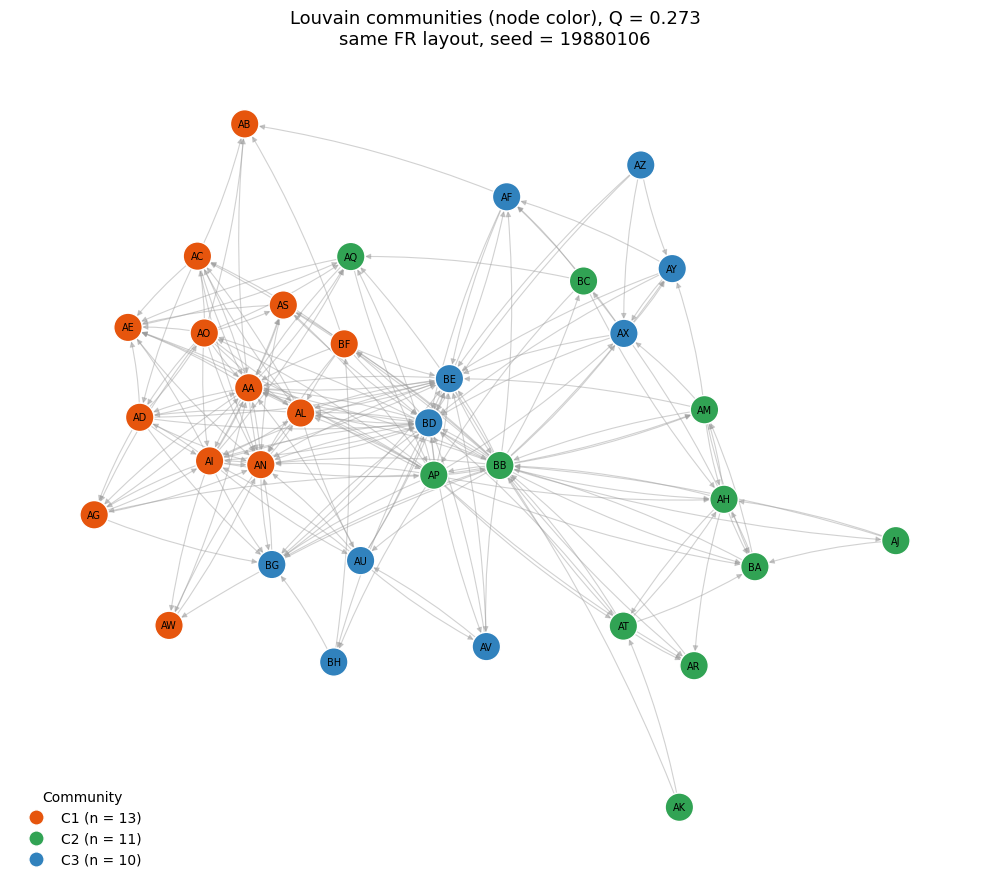

In [9]:
comm_palette = ["#e6550d", "#31a354", "#3182bd", "#756bb1", "#636363", "#d6616b"]
node_comm_col = [comm_palette[memb[v]] for v in G]

fig, ax = plt.subplots(figsize=(10, 9))
draw_base(ax, node_size=420, node_color=node_comm_col,
          title=f"Louvain communities (node color), Q = {Q:.3f}\nsame FR layout, seed = 19880106")
h = [Line2D([0], [0], marker="o", color="w", markerfacecolor=comm_palette[i], markersize=11,
            label=f"C{i+1} (n = {len(c)})") for i, c in enumerate(comms)]
ax.legend(handles=h, title="Community", loc="lower left", frameon=False)
plt.tight_layout(); plt.show()

Louvain finds three communities with modularity Q ≈ 0.27. This is moderate in absolute terms but clearly above the ≈ 0.20 that Louvain finds in random graphs of the same size, and 63% of all ties fall inside communities. There is real group structure, but there are also many ties between groups, which fits a single policy domain in which actors from all groups interact. The communities map closely onto organization type and onto the policy coalitions described in the Swiss climate-policy paper:

| Community | Composition | Paper |
|---|---|---|
| C1 (13 actors) | 10 of the 11 private-sector actors, plus one party, one government agency and one scientific actor | A business / economic coalition centred on AA and AN |
| C2 (11 actors) | All 7 NGOs + 4 parties | An environmental-advocacy coalition, held together by the broker BB and the party AP |
| C3 (10 actors) | 4 government agencies + 5 of the 6 science actors + 1 private actor | An administrative–scientific cluster around BD and BE |

Color (community) and position (FR layout) agree. The algorithm recovers the regions that are visible by eye in Section 1. The high transitivity in Section 3 is also consistent with this result: closed triangles concentrate inside these groups. The cross-community ties run mainly through the high-betweenness actors from Section 2 (BB, BD, BE, AA), who act as bridges between coalitions.